In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataset/diabetes_prediction_dataset.csv')

#Displays the first 5 rows of the data frame
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
#dimensions of the data frame(100,000 rows, 9 columns)
df.shape

(100000, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
#generates a summary of statistics for the numerical columns in the data frame
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
#check for missing (NaN) values in the data frame
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.duplicated( keep=False ).sum()

6939

In [7]:
#extracts the rows that are duplicates from the data frame df and then displays the first few rows of the duplicate entries
duplicate_rows = df[ df.duplicated( keep=False ) ]
duplicate_rows.head(30)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
10,Female,53.0,0,0,never,27.32,6.1,85,0
14,Female,76.0,0,0,No Info,27.32,5.0,160,0
18,Female,42.0,0,0,No Info,27.32,5.7,80,0
41,Male,5.0,0,0,No Info,27.32,6.6,130,0
44,Female,67.0,0,0,No Info,27.32,3.5,160,0
51,Female,26.0,0,0,No Info,27.32,4.0,200,0
56,Male,30.0,0,0,No Info,27.32,6.6,140,0
62,Female,30.0,0,0,current,27.32,6.5,158,0
95,Male,19.0,0,0,never,27.32,6.1,80,0


In [8]:
#list of column names from df that are numeric types, excluding the last column (Diabetes)
df_continuous_columns = df.select_dtypes( include = np.number ).columns[ : -1 ]
df_continuous_columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level'],
      dtype='object')

In [ ]:
df_categorical_columns = df.select_dtypes( exclude = np.number ).columns
df_categorical_columns

Index(['gender', 'smoking_history'], dtype='object')

In [9]:
#list of column names from df that are categorical types, excluding the last column
df_categorical_columns = df.select_dtypes( exclude = np.number ).columns
df_categorical_columns

Index(['gender', 'smoking_history'], dtype='object')

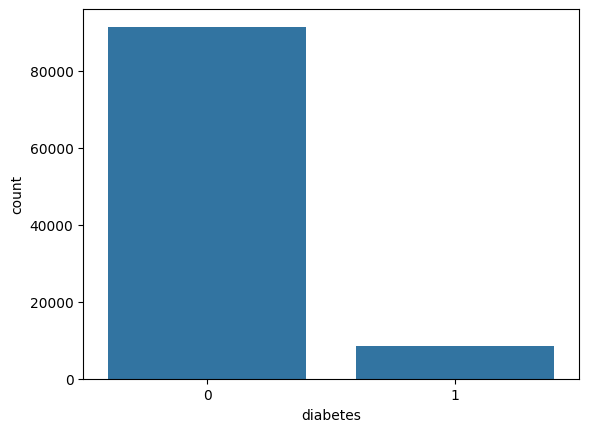

In [10]:
sns.countplot(x='diabetes', data=df)
plt.show()

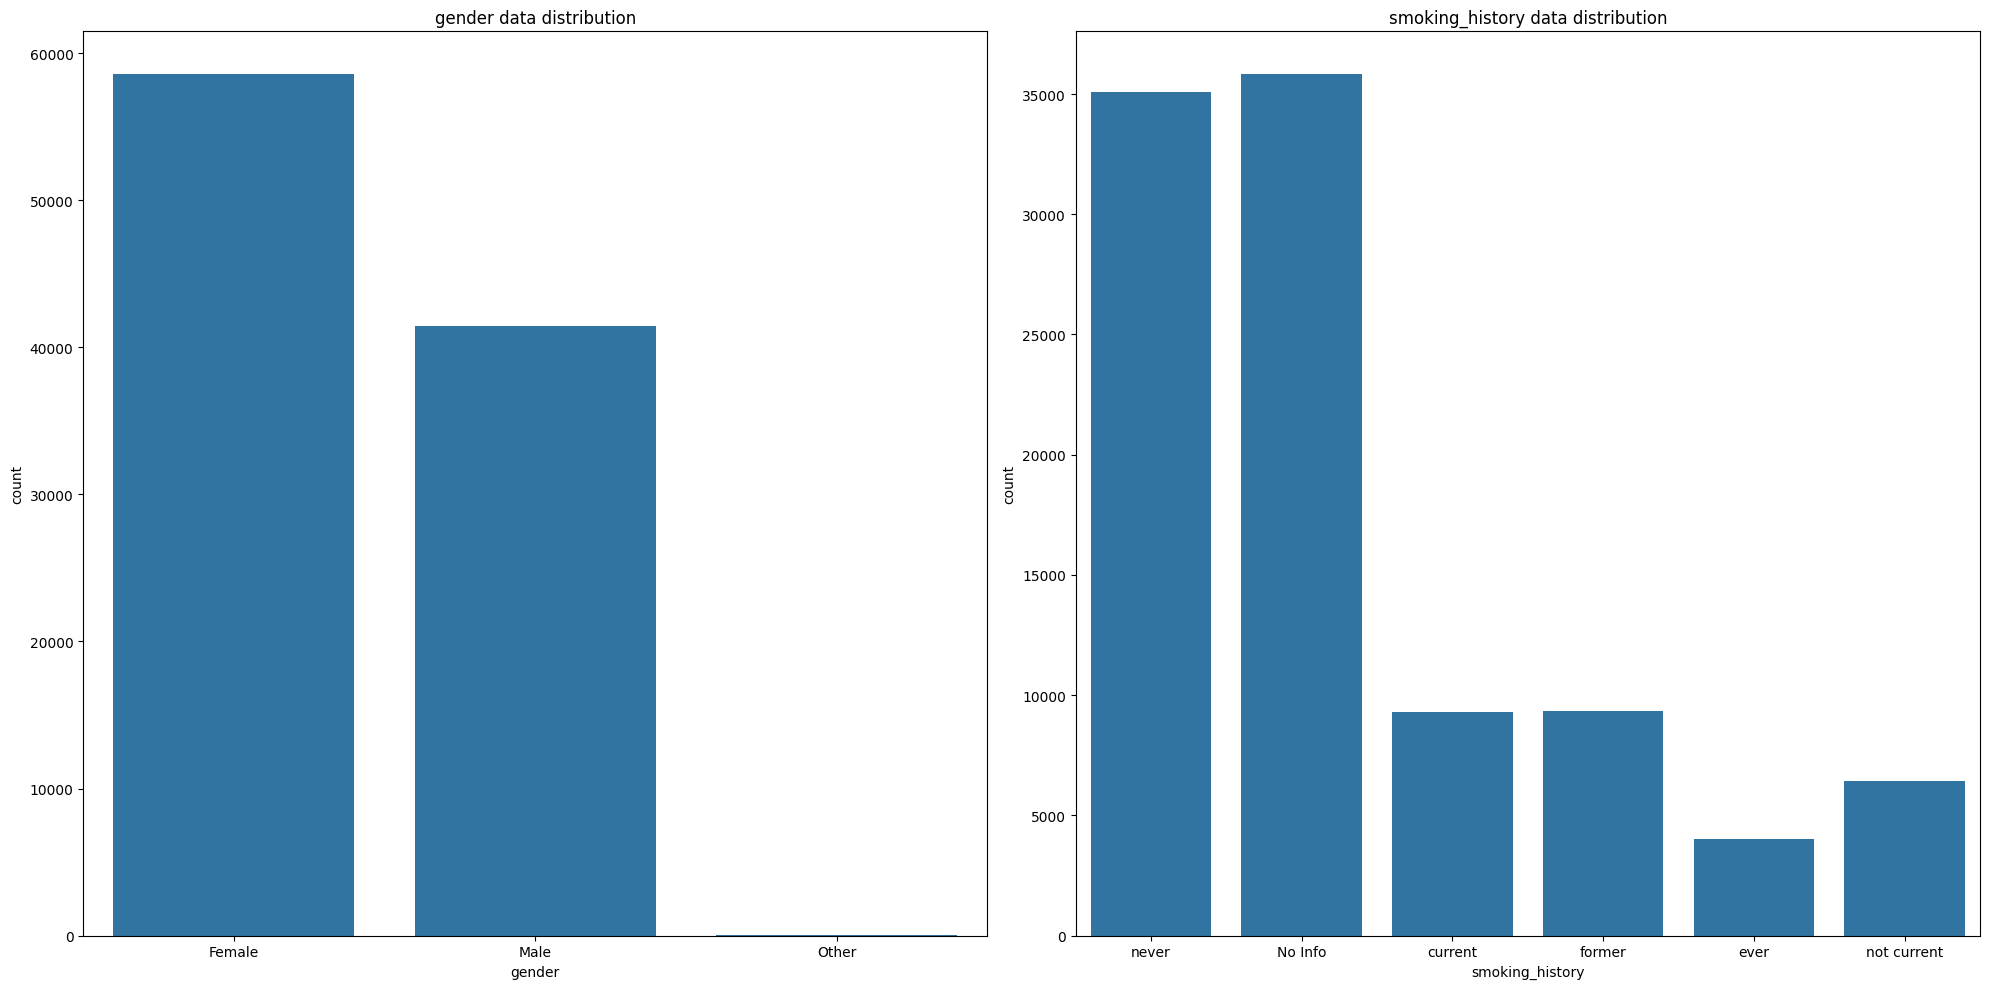

In [ ]:
figure, axs = plt.subplots( nrows=1, ncols=2, figsize=(20,10))
for i, column in enumerate( df_categorical_columns ):

    sns.countplot( x= df[column],  ax=axs[ i ] )
    axs[ i ].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

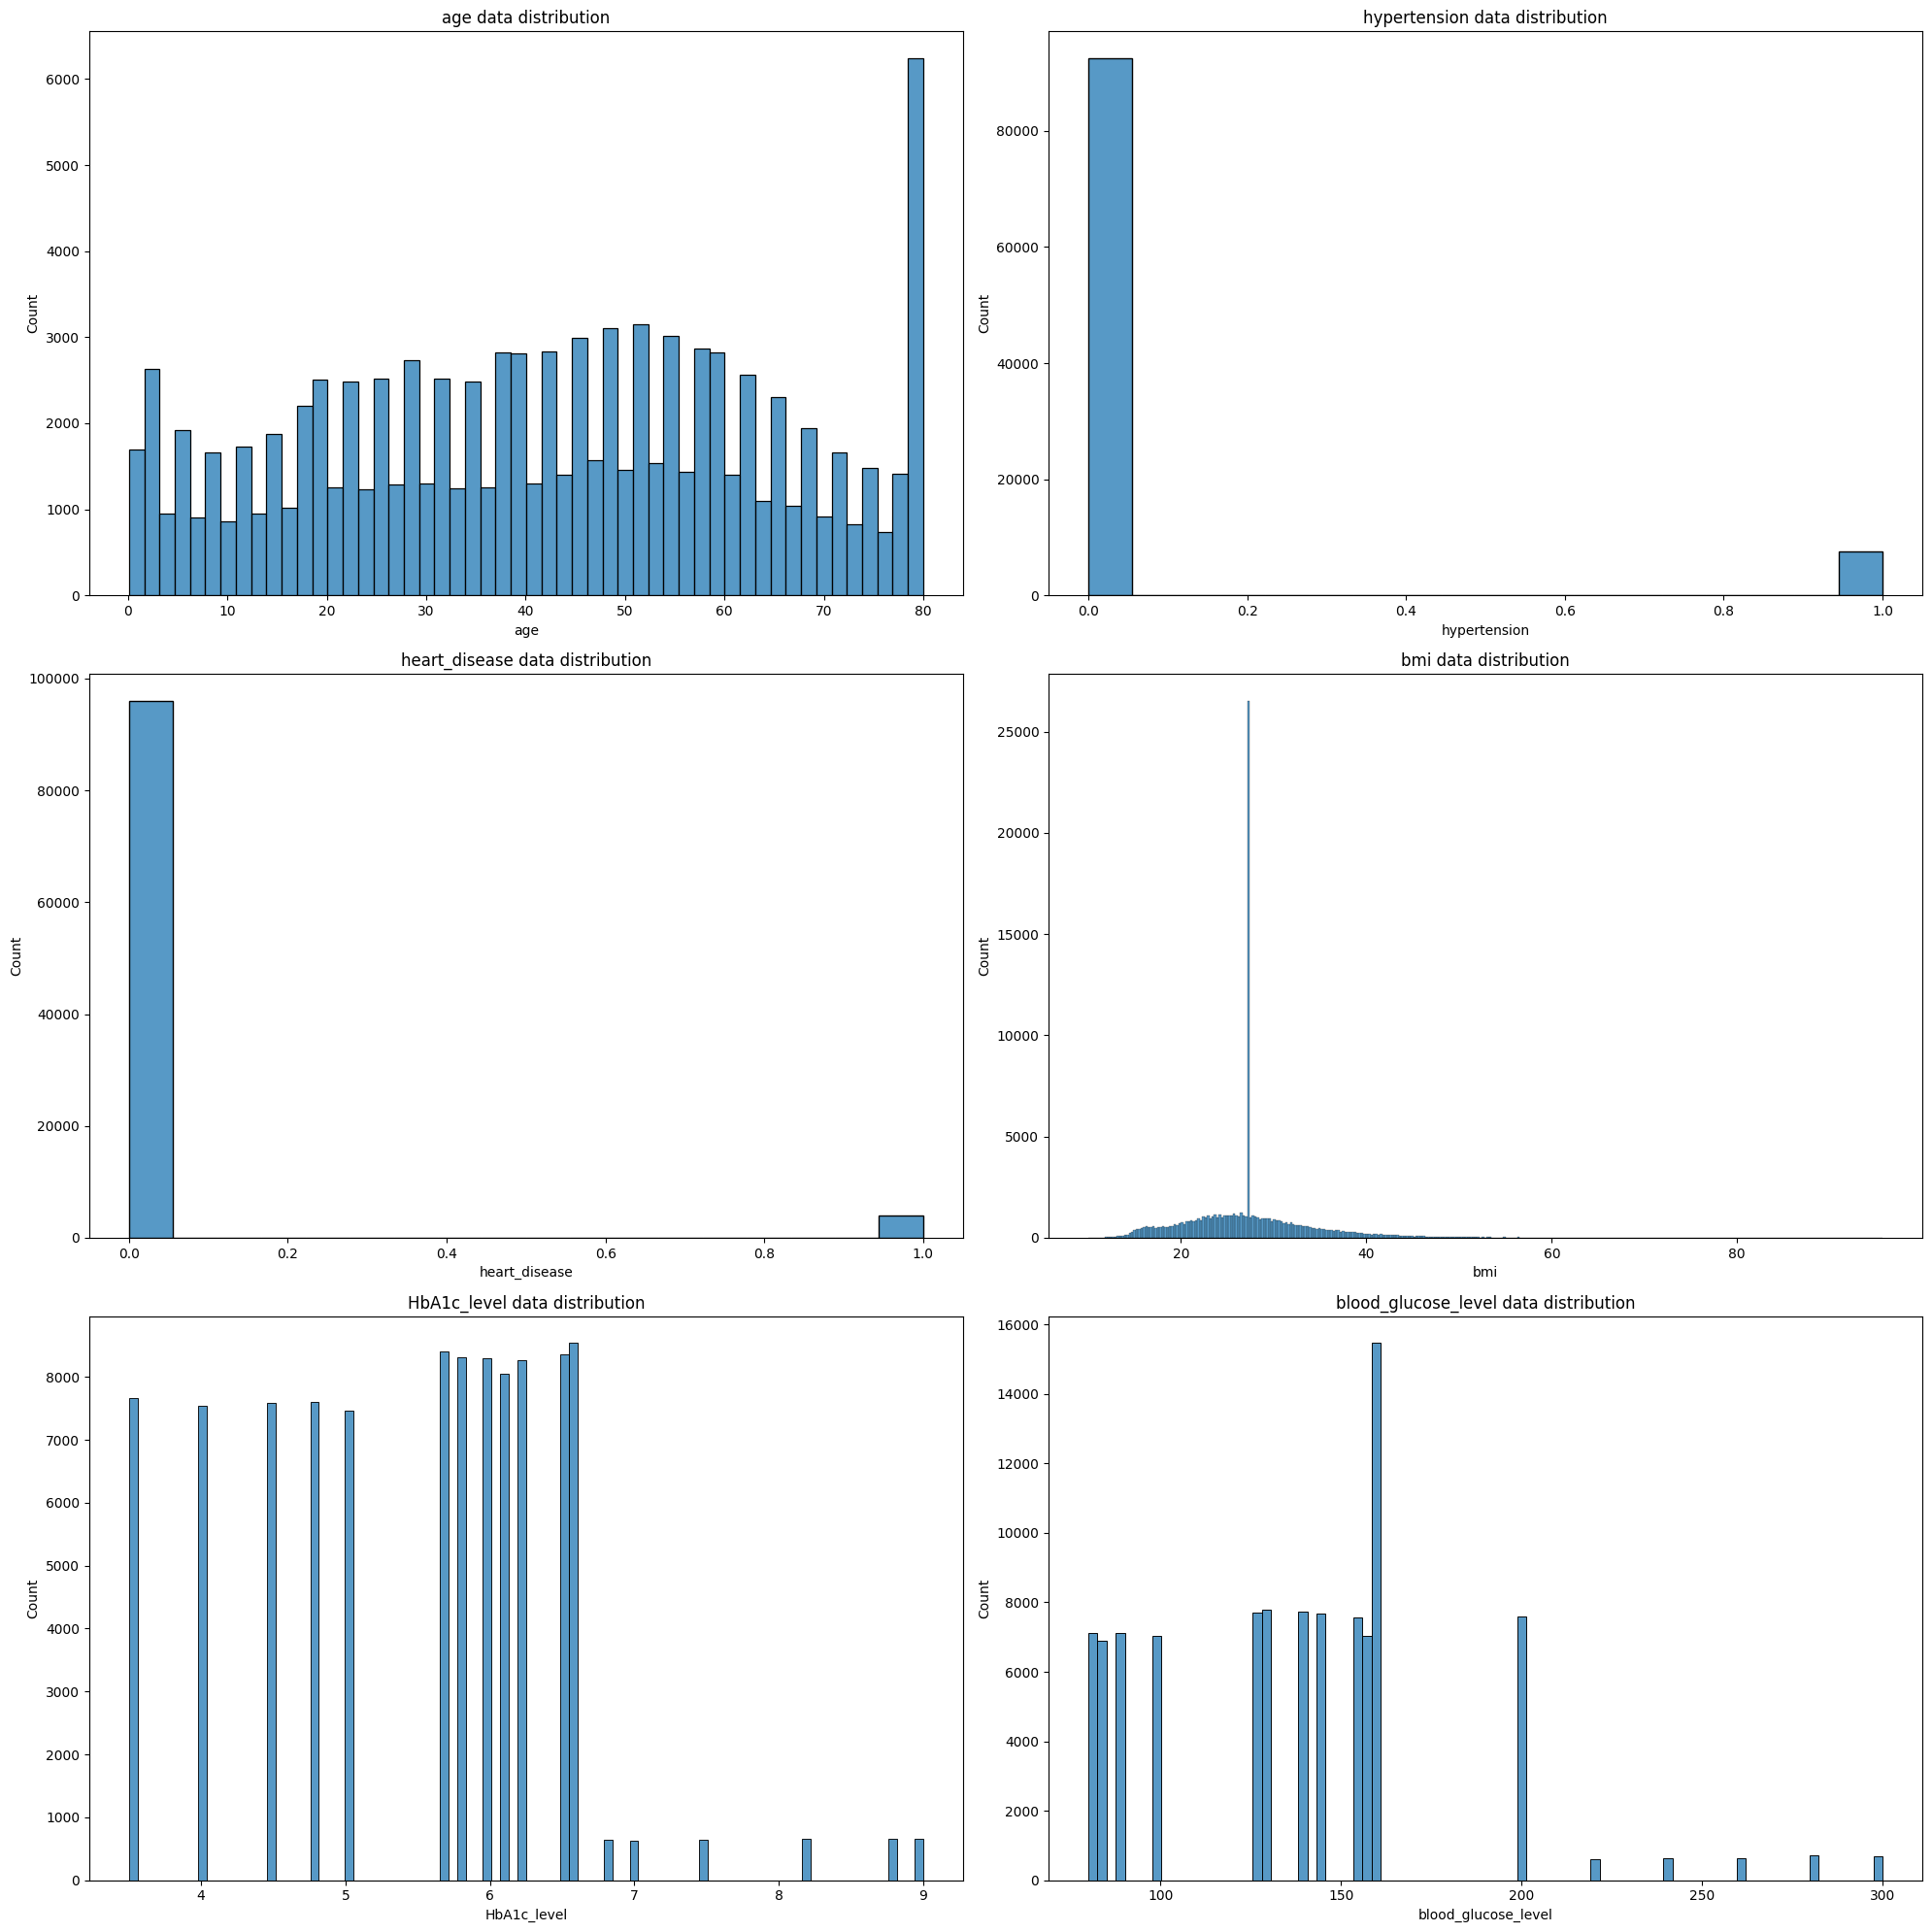

In [ ]:
figure, axs = plt.subplots( nrows=3, ncols=2, figsize=(20,20))
for i, column in enumerate( df_continuous_columns ):
    row = i // 2
    col = i % 2
    sns.histplot( df[column],  ax=axs[row, col] )
    axs[row, col].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

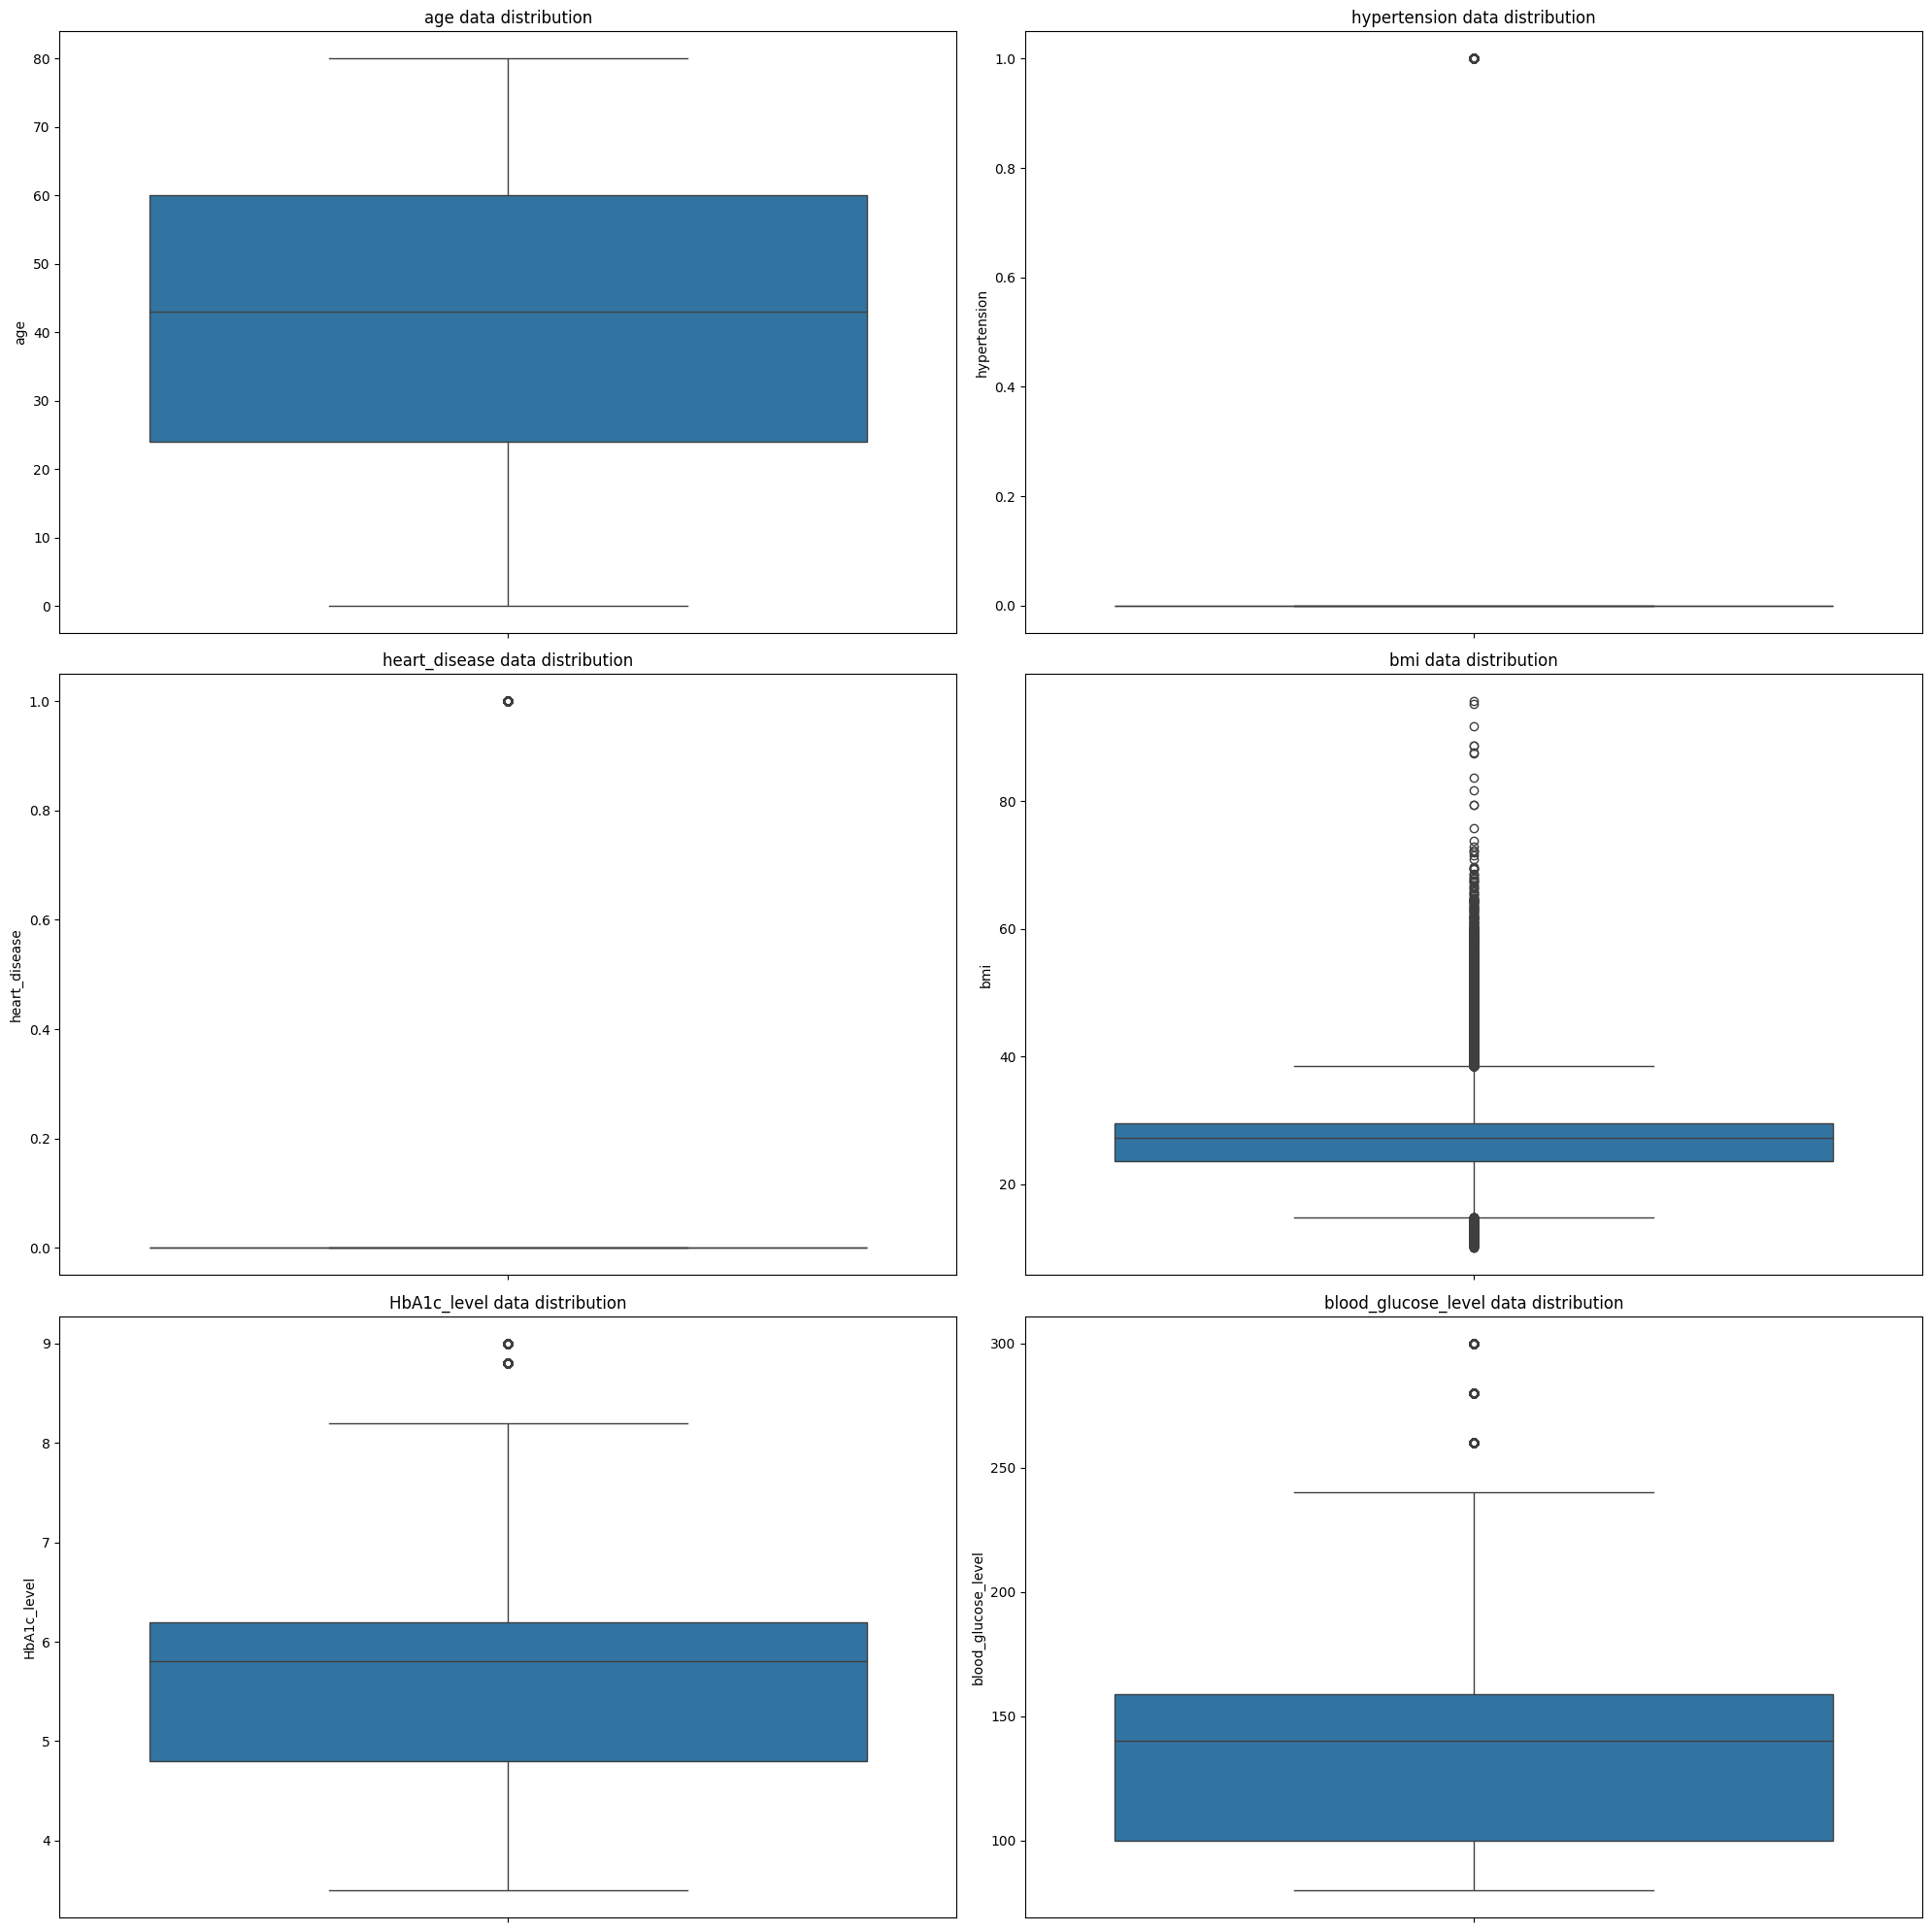

In [ ]:
figure, axs = plt.subplots( nrows=3, ncols=2, figsize=(20,20))
for i, column in enumerate( df_continuous_columns ):
    row = i // 2
    col = i % 2
    sns.boxplot( df[column],  ax=axs[row, col] )
    axs[row, col].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

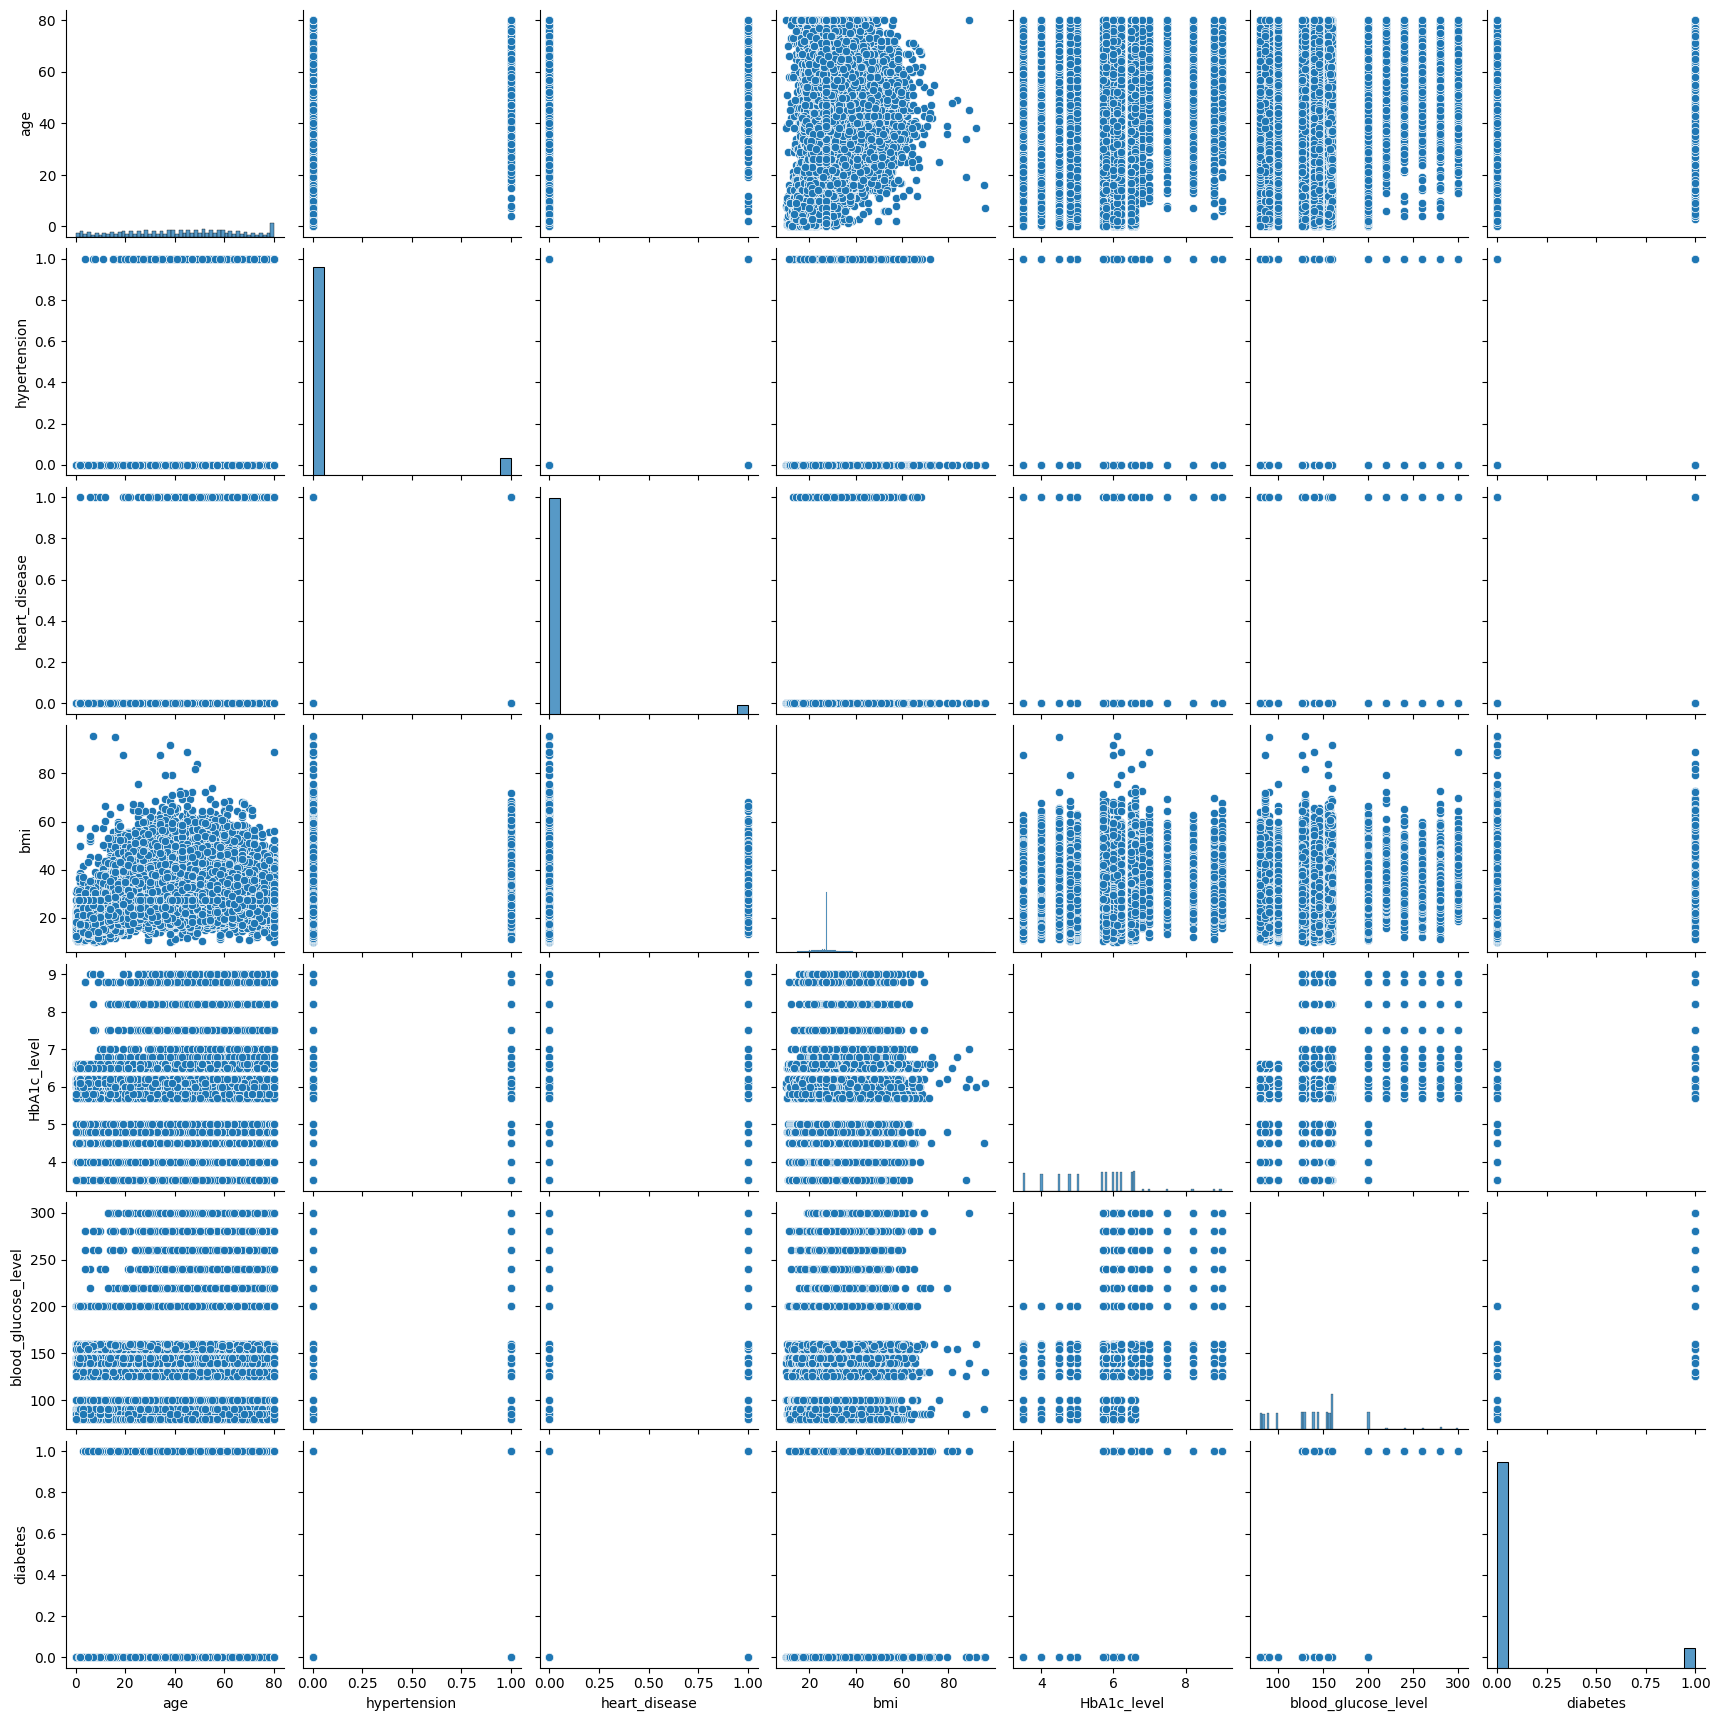

In [10]:
sns.pairplot( df )
plt.show()

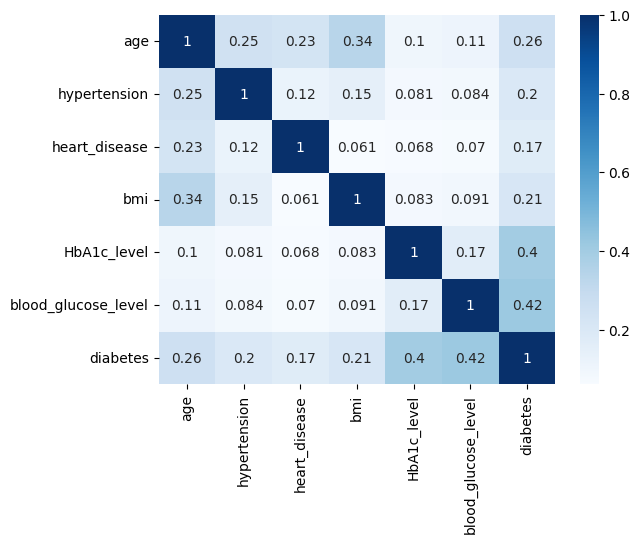

In [ ]:
sns.heatmap( df[ df.select_dtypes( include = np.number ).columns ].corr(), annot=True, cmap='Blues' )
plt.show()

In [11]:
column_to_clean = [ 'bmi', 'HbA1c_level', 'blood_glucose_level' ]

In [14]:
#Obtain the Q1 for each column, which will be used to handle outliers.
Q1 = df[ column_to_clean ].quantile( 0.25 )
Q1

,0.25
bmi,23.63
HbA1c_level,4.80
blood_glucose_level,100.00


In [15]:
#Obtain the Q3 for each column, which will be used to handle outliers.
Q3 = df[ column_to_clean ].quantile( 0.75 )
Q3

,0.75
bmi,29.58
HbA1c_level,6.20
blood_glucose_level,159.00


In [16]:
#Obtain the IQR for each column, which will be used to calculate the lower and upper bound for each column.
IQR = Q3 - Q1
IQR

,0
bmi,5.95
HbA1c_level,1.40
blood_glucose_level,59.00


In [17]:
#calculates the lower bound for detecting outliers using the Interquartile Range (IQR) method
lower_bound = Q1 - 1.5 * IQR
lower_bound

,0
bmi,14.705
HbA1c_level,2.700
blood_glucose_level,11.500


In [18]:
#calculates the upper bound for detecting outliers using the Interquartile Range (IQR) method
upper_bound = Q3 + 1.5 * IQR
upper_bound

,0
bmi,38.505
HbA1c_level,8.300
blood_glucose_level,247.500


In [19]:
outliers_per_col = df[ (df[ column_to_clean ] < lower_bound) | (df[ column_to_clean ] > upper_bound) ].count()
outliers_per_col.sort_values( )

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
diabetes,0
HbA1c_level,1315
blood_glucose_level,2038
bmi,7086


In [21]:
#total count of outliers across all columns
outliers_per_col.sum()

10439

In [22]:
new_df = df.copy()

In [23]:
new_df.loc[ ( (new_df[ 'smoking_history' ] == 'not current' ) | ( new_df[ 'smoking_history' ] == 'ever' ) ), 'smoking_history' ] = 'former'

In [25]:
for col in column_to_clean:
    new_df.loc[ ( (new_df[ col ] < lower_bound[ col ] ) | ( new_df[ col ] > upper_bound[ col ] ) ), col ] = np.nan

In [26]:
#Displays the first 5 rows of the data frame
new_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80.0,0
2,Male,28.0,0,0,never,27.32,5.7,158.0,0
3,Female,36.0,0,0,current,23.45,5.0,155.0,0
4,Male,76.0,1,1,current,20.14,4.8,155.0,0


In [27]:
#generates a summary of statistics for the numerical columns in the DataFrame
new_df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,92914.000000,98685.000000,97962.000000,100000.000000
mean,41.885856,0.07485,0.039420,26.400779,5.482575,135.097140,0.085000
std,22.516840,0.26315,0.194593,4.892598,1.003968,35.441539,0.278883
min,0.080000,0.00000,0.000000,14.710000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.480000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,28.440000,6.200000,158.000000,0.000000
max,80.000000,1.00000,1.000000,38.500000,8.200000,240.000000,1.000000


In [28]:
#check for missing (NaN) values in the data frame
new_df.isna().sum().sort_values()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
diabetes,0
HbA1c_level,1315
blood_glucose_level,2038
bmi,7086


In [29]:
def convert_to_numeric( continuous_df, categorical_columns, categorical, pred_col ):
    for column in categorical_columns:
      #we won't be converting the column we want to predict its NaN values for categorical predictions
      if column == pred_col and categorical == True:
        continue
      else:
        continuous_df[ column ] = pd.factorize( continuous_df[ column ] )[ 0 ]

    return continuous_df

In [30]:
def predict_missing_values( new_df, columns, pred_df, categorical_data, categorical_columns):
    dataframe = new_df.copy()
    for col in columns:
        # if more than 50% of the column data is missing, drop column
        if dataframe[col].isna().sum() > dataframe.shape[0] / 2:
            dataframe.drop(col, axis=1, inplace=True)
            pred_df.drop(col, axis=1, inplace=True) # Drop from pred_df as well
        else:
            # Get a boolean mask of missing values
            col_missing_mask = dataframe[col].isna()

            # No missing index
            if not col_missing_mask.any():  # Check if any values are missing
                continue
            else:
                # Create 'is_nan' column and set values based on the mask
                dataframe['is_nan'] = 0
                dataframe.loc[col_missing_mask, 'is_nan'] = 1

                continuous_df = dataframe.copy()

                continuous_df = convert_to_numeric(continuous_df, categorical_columns, categorical_data, col)

                train = continuous_df[continuous_df['is_nan'] == 0]
                test = continuous_df[continuous_df['is_nan'] == 1]

                X_train = train.drop([col, 'is_nan'], axis=1)
                y_train = train[col]

                X_test = test.drop([col, 'is_nan'], axis=1)
                y_test = test[col]

                lgbm = LGBMRegressor()
                lgbm.fit(X_train, y_train)

                y_pred = lgbm.predict(X_test)

                # Use the mask to assign values to pred_df
                pred_df.loc[col_missing_mask, col] = y_pred

In [32]:
#Create a copy of the Data Frame
pred_df = new_df.copy()

In [33]:
predict_missing_values( new_df, column_to_clean, pred_df, False, df_categorical_columns  )

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010272 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 151
[LightGBM] [Info] Number of data points in the train set: 92914, number of used features: 8
[LightGBM] [Info] Start training from score 26.400779
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 388
[LightGBM] [Info] Number of data points in the train set: 98685, number of used features: 8
[LightGBM] [Info] Start training from score 5.482575
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010827 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 389
[LightGBM] [Info] Number of data points in the train set: 97962, number of used features: 8
[LightGBM] [Info] Start training

In [34]:
#Displays the first 5 rows of the data frame
pred_df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80.0,0
2,Male,28.0,0,0,never,27.32,5.7,158.0,0
3,Female,36.0,0,0,current,23.45,5.0,155.0,0
4,Male,76.0,1,1,current,20.14,4.8,155.0,0


In [35]:
#generates a summary of statistics for the numerical columns in the DataFrame
pred_df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,26.425692,5.496857,135.740053,0.085000
std,22.516840,0.26315,0.194593,4.798304,1.005016,35.366749,0.278883
min,0.080000,0.00000,0.000000,14.710000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,28.476612,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,38.500000,8.200000,240.000000,1.000000


In [36]:
#check for missing (NaN) values in the data frame
new_df.isna().sum().sort_values()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
diabetes,0
HbA1c_level,1315
blood_glucose_level,2038
bmi,7086


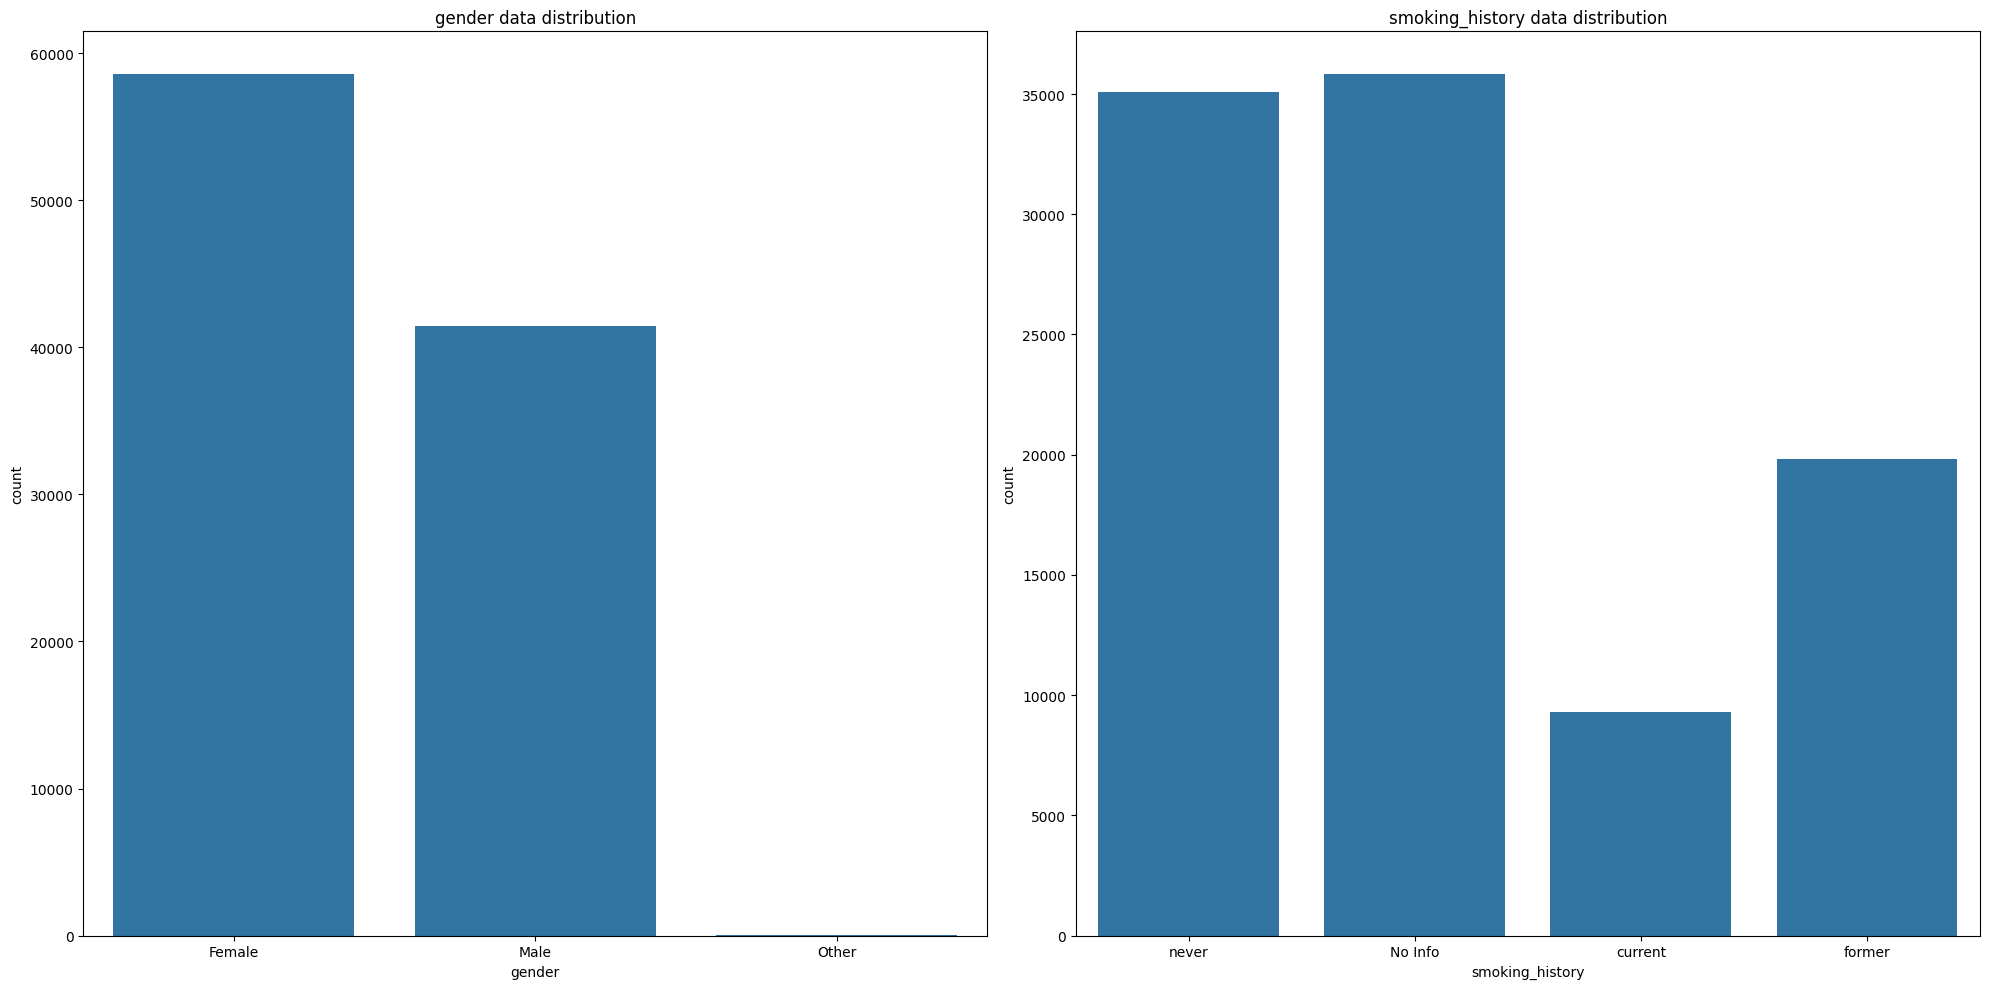

In [ ]:
figure, axs = plt.subplots( nrows=1, ncols=2, figsize=(20,10))
for i, column in enumerate( df_categorical_columns ):

    sns.countplot( x= pred_df[column],  ax=axs[ i ] )
    axs[ i ].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

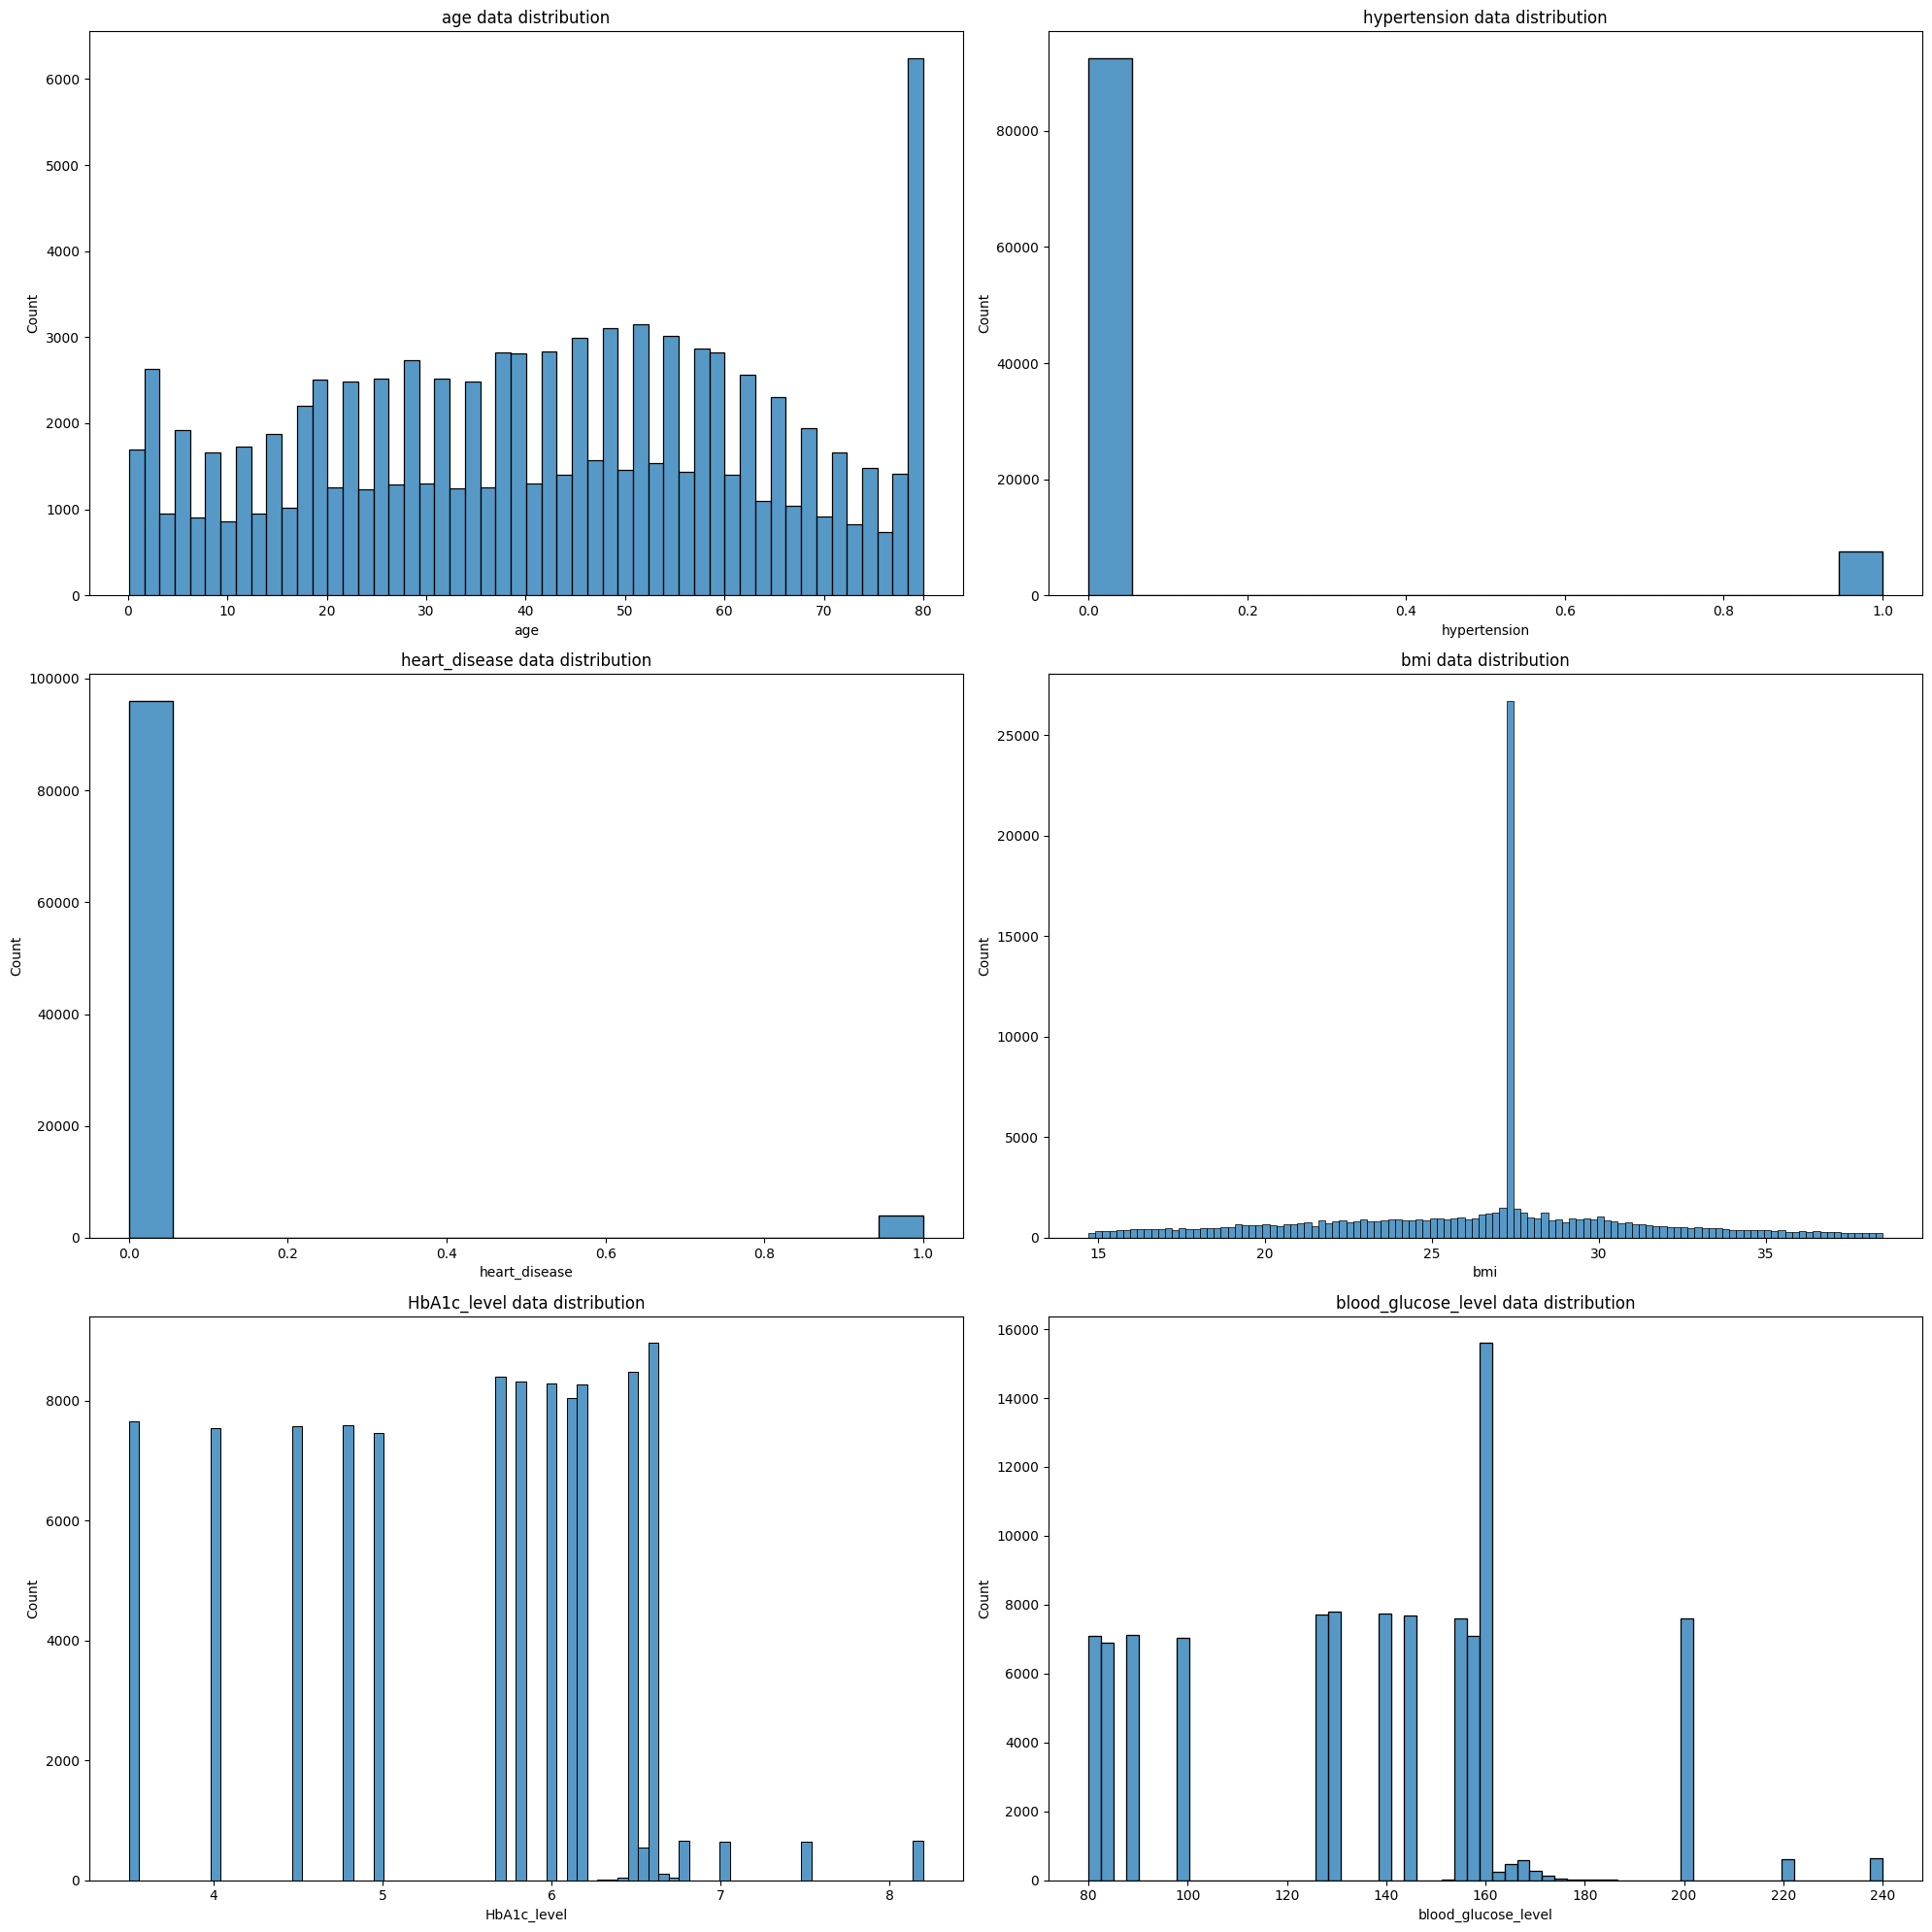

In [ ]:
figure, axs = plt.subplots( nrows=3, ncols=2, figsize=(20,20))
for i, column in enumerate( df_continuous_columns ):
    row = i // 2
    col = i % 2
    sns.histplot( pred_df[column],  ax=axs[row, col] )
    axs[row, col].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

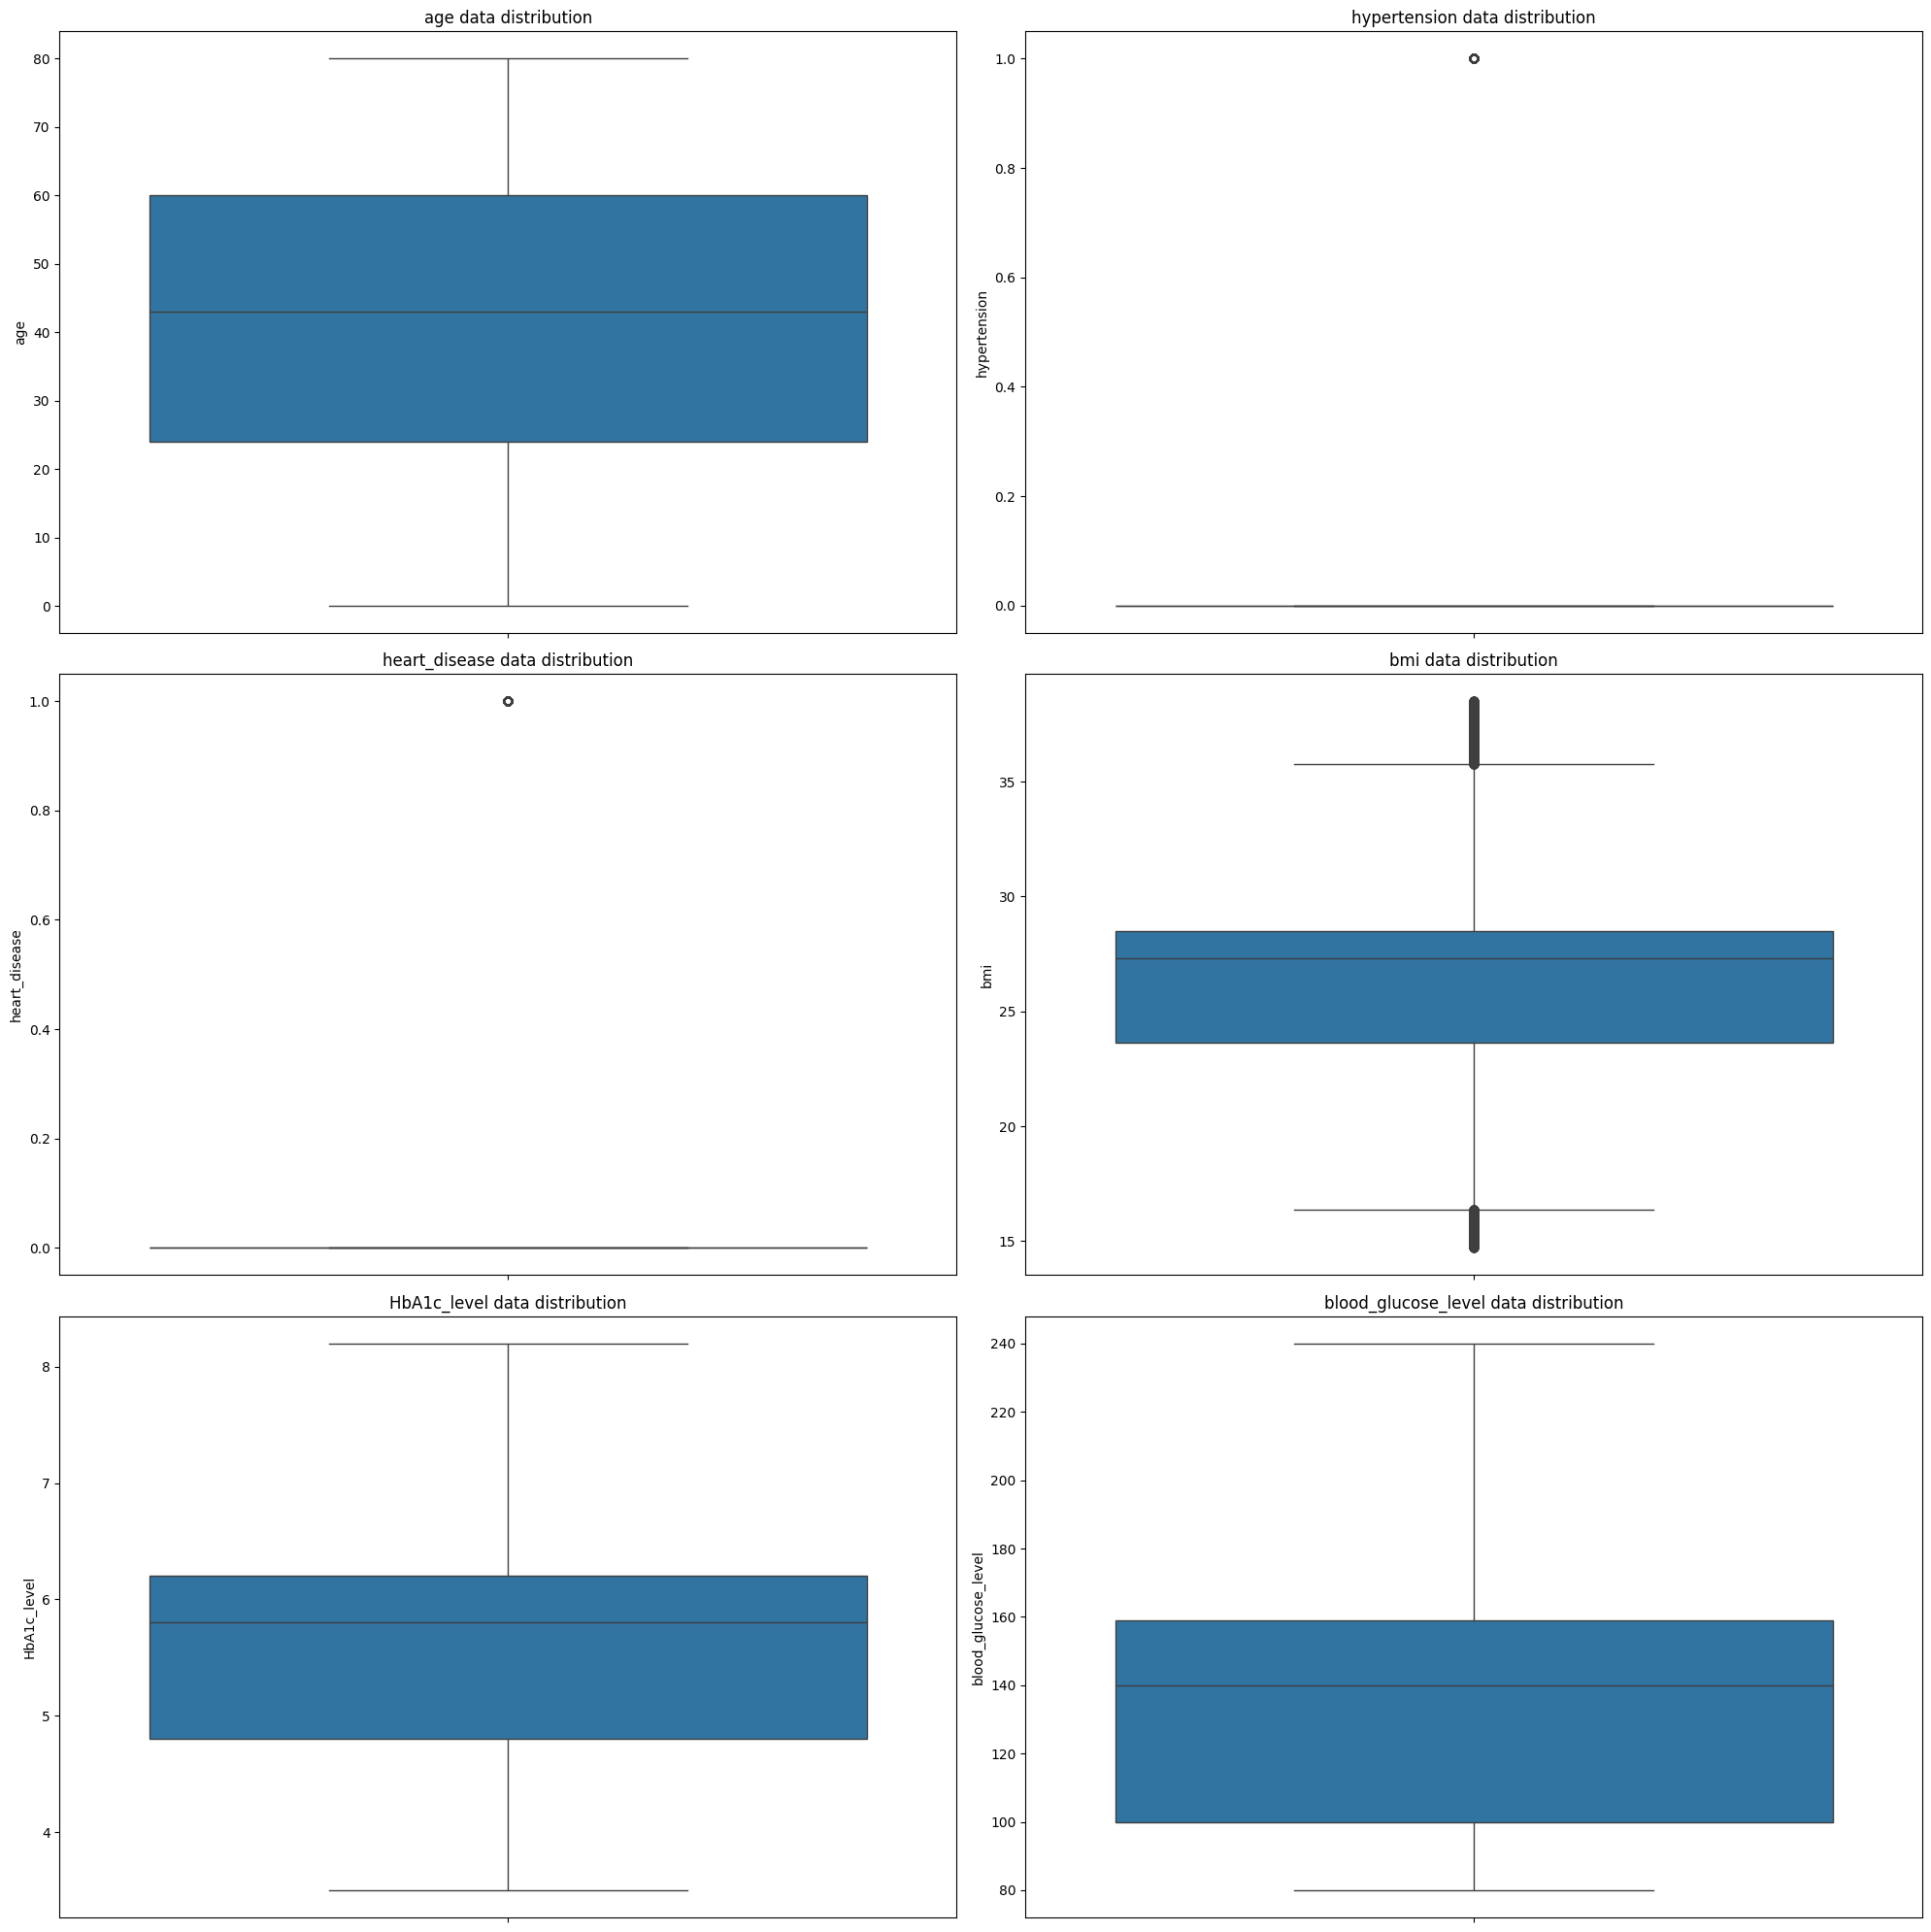

In [ ]:
figure, axs = plt.subplots( nrows=3, ncols=2, figsize=(20,20))
for i, column in enumerate( df_continuous_columns ):
    row = i // 2
    col = i % 2
    sns.boxplot( pred_df[column],  ax=axs[row, col] )
    axs[row, col].set_title(f'{column} data distribution' )
    plt.tight_layout()
plt.show()

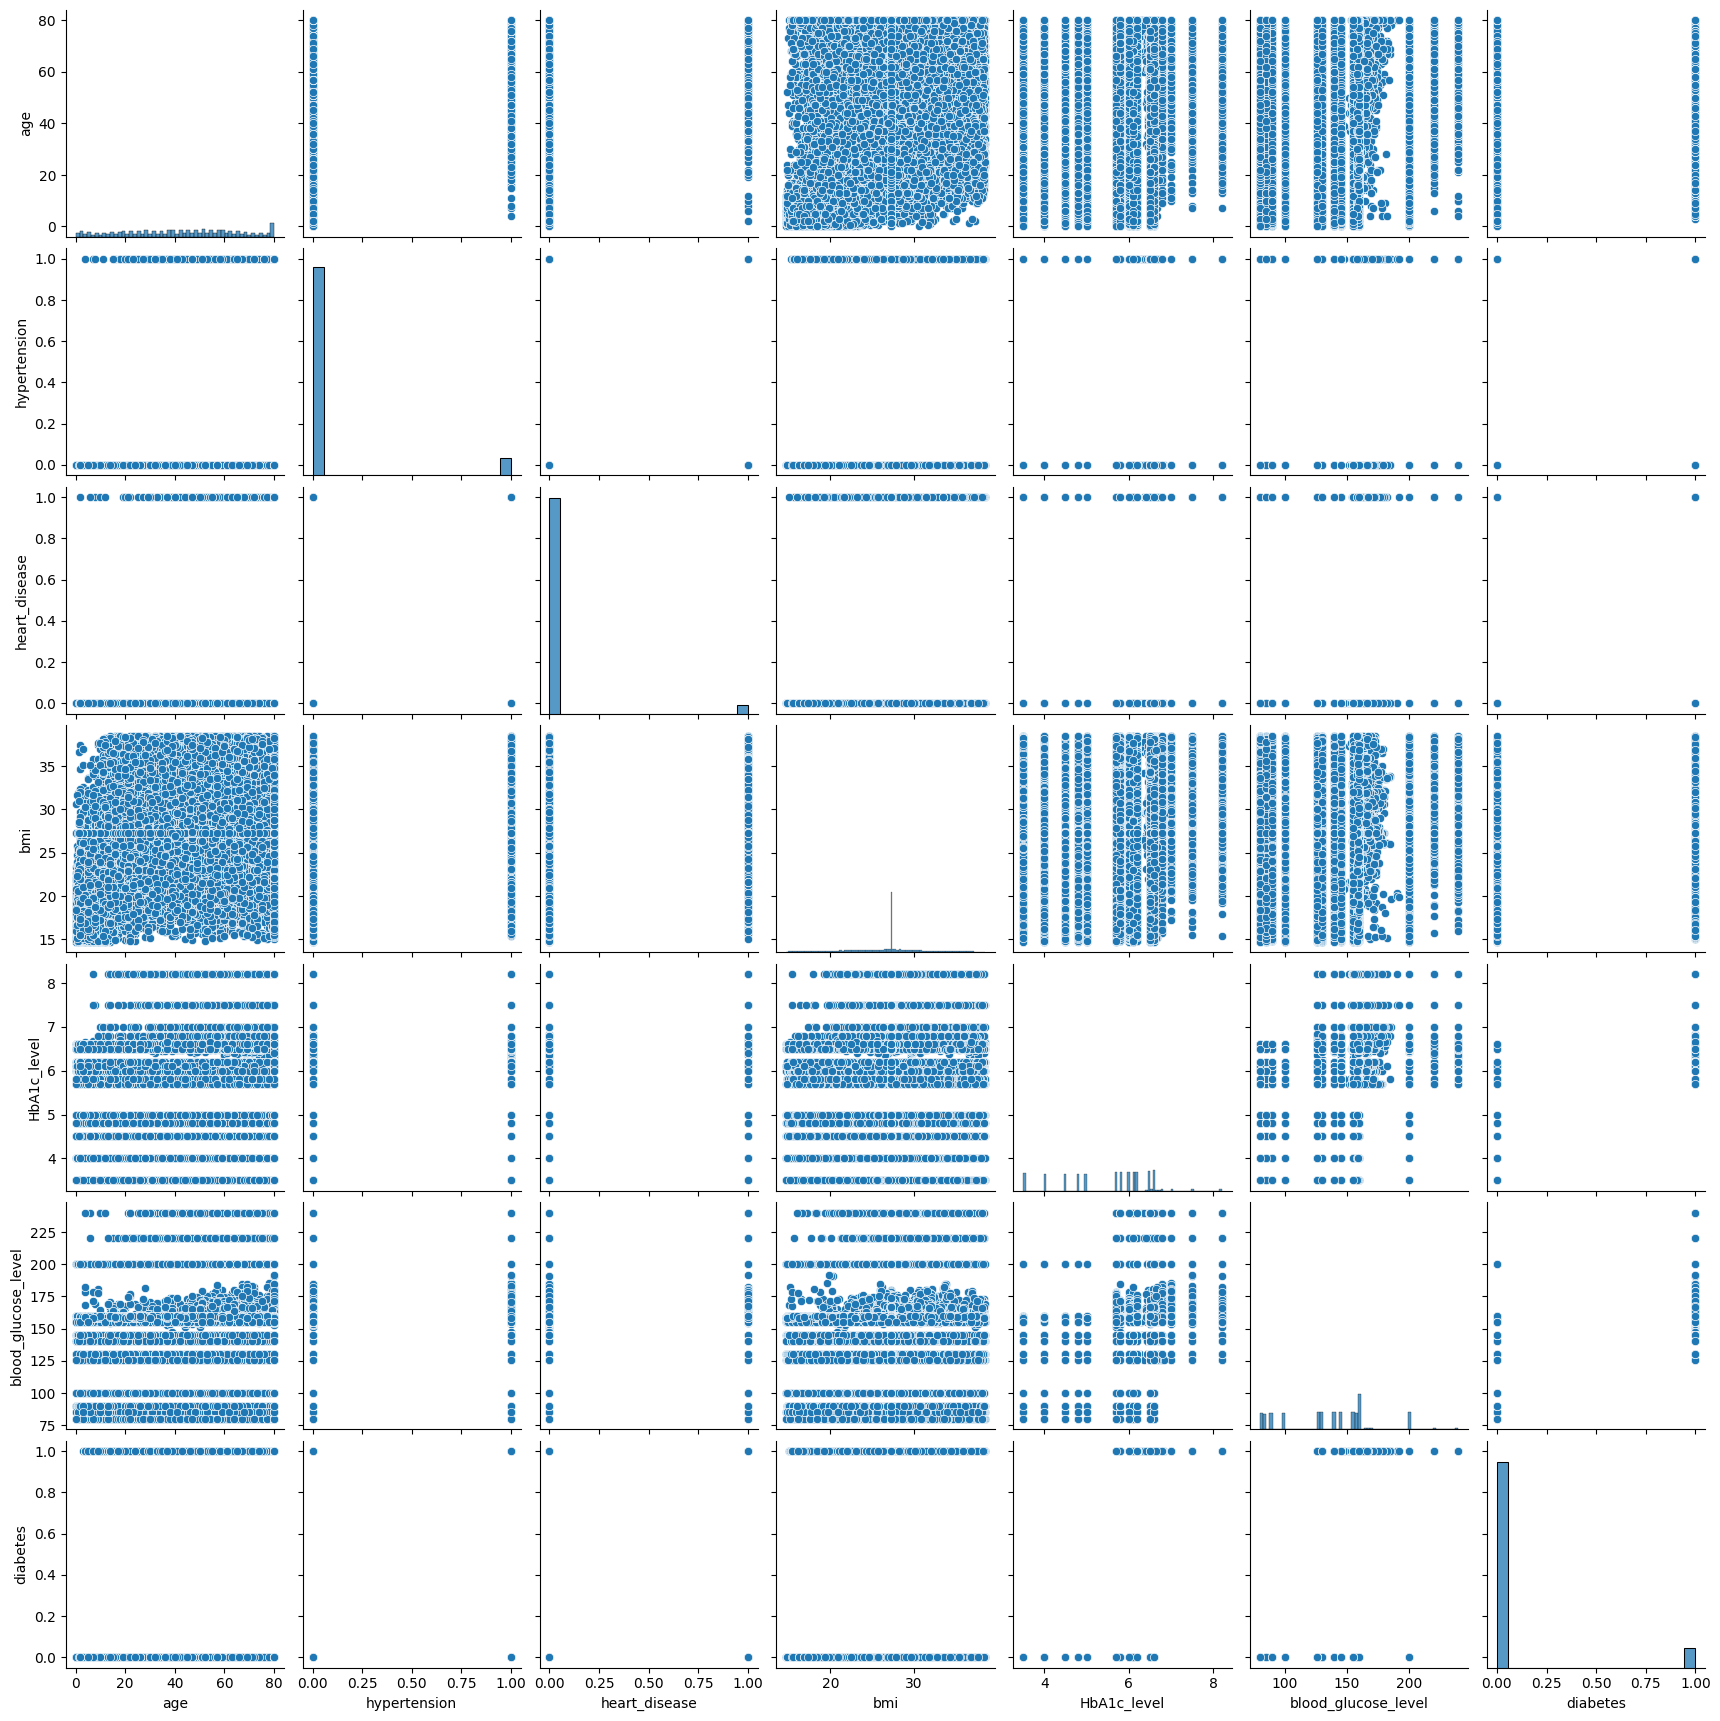

In [ ]:
sns.pairplot( pred_df )
plt.show()

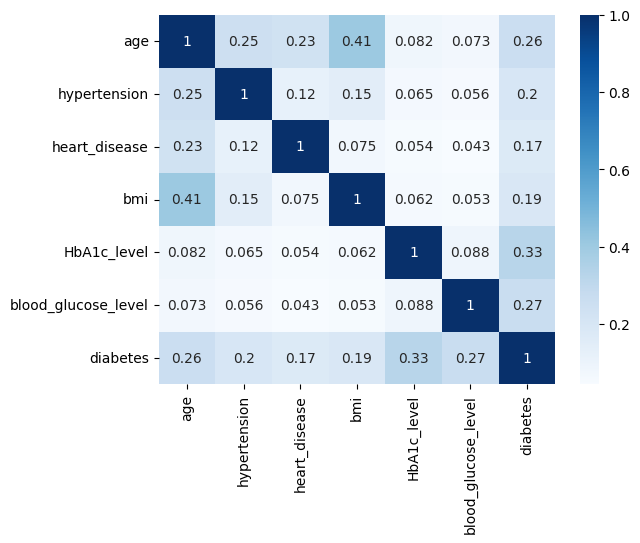

In [ ]:
sns.heatmap( pred_df[ pred_df.select_dtypes( include= np.number ).columns  ].corr(), annot=True, cmap='Blues' )
plt.show()

In [37]:
final_df = pd.get_dummies( pred_df, columns= df_categorical_columns )
final_df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_former,smoking_history_never
0,80.0,0,1,25.19,6.6,140.0,0,True,False,False,False,False,False,True
1,54.0,0,0,27.32,6.6,80.0,0,True,False,False,True,False,False,False
2,28.0,0,0,27.32,5.7,158.0,0,False,True,False,False,False,False,True
3,36.0,0,0,23.45,5.0,155.0,0,True,False,False,False,True,False,False
4,76.0,1,1,20.14,4.8,155.0,0,False,True,False,False,True,False,False


In [38]:
rbs = RobustScaler()
scaled_df = rbs.fit_transform( final_df )
scaled_df = pd.DataFrame( scaled_df, columns=final_df.columns )
scaled_df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_former,smoking_history_never
0,1.027778,0.0,1.0,-0.439482,0.571429,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.305556,0.0,0.0,0.000000,0.571429,-1.016949,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.416667,0.0,0.0,0.000000,-0.071429,0.305085,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-0.194444,0.0,0.0,-0.798496,-0.571429,0.254237,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.916667,1.0,1.0,-1.481447,-0.714286,0.254237,0.0,-1.0,1.0,0.0,0.0,1.0,0.0,0.0


In [39]:
train =  scaled_df.drop('diabetes', axis=1)
test = scaled_df['diabetes']

In [40]:
X_train, X_test, y_train, y_test = train_test_split( train, test, test_size=0.2, random_state=42 )

In [41]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the class distribution after SMOTE
print("Class distribution before SMOTE:")
print(y_train.value_counts())
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Class distribution before SMOTE:
diabetes
0.0    73208
1.0     6792
Name: count, dtype: int64

Class distribution after SMOTE:
diabetes
0.0    73208
1.0    73208
Name: count, dtype: int64


In [42]:
X_test_resampled, y_test_resampled = smote.fit_resample(X_test, y_test)

# Check the class distribution after SMOTE
print("Class distribution before SMOTE:")
print(y_test.value_counts())
print("\nClass distribution after SMOTE:")
print(pd.Series(y_test_resampled).value_counts())

Class distribution before SMOTE:
diabetes
0.0    18292
1.0     1708
Name: count, dtype: int64

Class distribution after SMOTE:
diabetes
0.0    18292
1.0    18292
Name: count, dtype: int64


In [43]:
rfc = RandomForestClassifier( class_weight='balanced', random_state=42 )
rfc.fit( X_train_resampled, y_train_resampled )

RandomForestClassifier(class_weight='balanced', random_state=42)

In [44]:
y_pred = rfc.predict(  X_test_resampled )

In [45]:
acc_score = accuracy_score(y_test_resampled, y_pred)
print(f"{acc_score:.4f}")

0.9424


In [46]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize model (example: Random Forest)
model = RandomForestClassifier(class_weight='balanced', random_state=42)

# Perform Stratified K-Fold Cross-Validation
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(skf.split(train, test), 1):
    print(f"Fold {fold}")

    # Split data into training and testing sets using .iloc for integer-location based indexing
    X_train, X_test = train.iloc[train_idx], train.iloc[test_idx]
    y_train, y_test = test.iloc[train_idx], test.iloc[test_idx]

    # Train the model
    model.fit(X_train, y_train)

    # Predict and evaluate
    y_predt = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_predt)
    fold_accuracies.append(accuracy)

    print(f"Accuracy for Fold {fold}: {accuracy:.4f}")

Fold 1
Accuracy for Fold 1: 0.9638
Fold 2
Accuracy for Fold 2: 0.9652
Fold 3
Accuracy for Fold 3: 0.9653
Fold 4
Accuracy for Fold 4: 0.9647
Fold 5
Accuracy for Fold 5: 0.9650


In [48]:
print(f" {np.mean(fold_accuracies):.4f}")

 0.9648


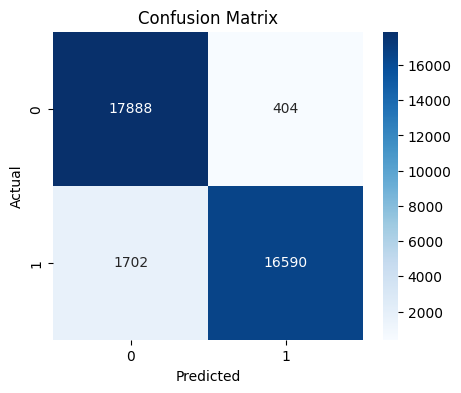

In [47]:
class_names = [0, 1]
conf_matrix = confusion_matrix(y_test_resampled, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [49]:
class_report = classification_report(y_test_resampled, y_pred, target_names=['0', '1'])
print("\nClassification Report:")
print(class_report)


Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     18292
           1       0.98      0.91      0.94     18292

    accuracy                           0.94     36584
   macro avg       0.94      0.94      0.94     36584
weighted avg       0.94      0.94      0.94     36584

